In [ ]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 18.7 MB/s eta 0:00:00


In [ ]:
pip install pyarrow

In [ ]:
pip install wordcloud matplotlib

In [ ]:
pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 19.6 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

# Remplacez 'Datasets/mon_fichier.parquet' par le chemin réel dans votre Drive
path = '/content/drive/MyDrive/data/full-00000-of-00001.parquet'

# Lecture du fichier
df = pd.read_parquet(path)

# Visualisation
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/data/full-00000-of-00001.parquet'

In [ ]:
df.shape

(112590, 16)

In [ ]:
df.columns

Index(['main_category', 'title', 'average_rating', 'rating_number', 'features',
       'description', 'price', 'images', 'videos', 'store', 'categories',
       'details', 'parent_asin', 'bought_together', 'subtitle', 'author'],
      dtype='object')

In [ ]:
from datasets import load_dataset

dataset = load_dataset('json', data_files='/content/drive/MyDrive/data/All_Beauty.jsonl')
print(dataset['train'][0])

Generating train split: 0 examples [00:00, ? examples/s]

{'rating': 5.0, 'title': 'Such a lovely scent but not overpowering.', 'text': "This spray is really nice. It smells really good, goes on really fine, and does the trick. I will say it feels like you need a lot of it though to get the texture I want. I have a lot of hair, medium thickness. I am comparing to other brands with yucky chemicals so I'm gonna stick with this. Try it!", 'images': [], 'asin': 'B00YQ6X8EO', 'parent_asin': 'B00YQ6X8EO', 'user_id': 'AGKHLEW2SOWHNMFQIJGBECAF7INQ', 'timestamp': 1588687728923, 'helpful_vote': 0, 'verified_purchase': True}


In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase'],
        num_rows: 701528
    })
})

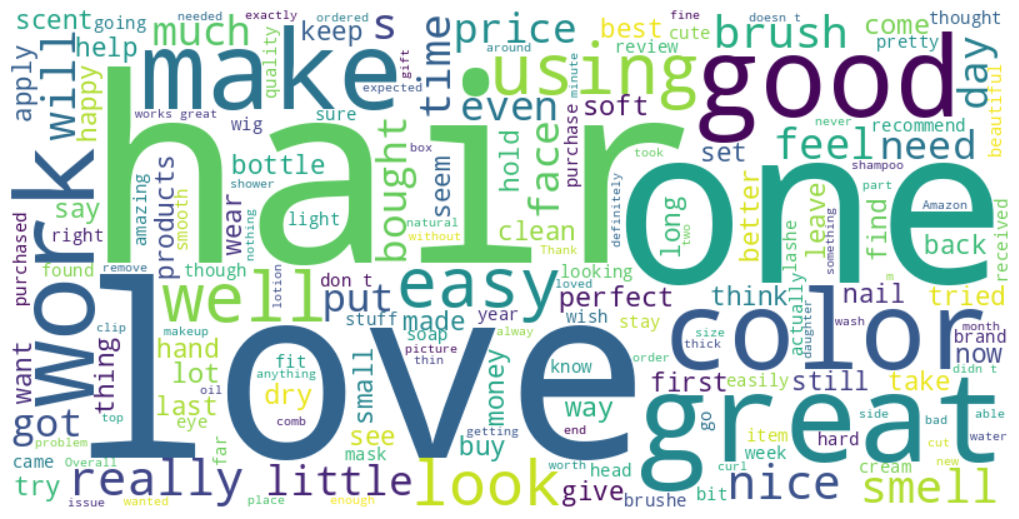

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from datasets import load_dataset

# 1. Chargement du dataset
dataset = load_dataset('json', data_files='/content/drive/MyDrive/data/All_Beauty.jsonl')

# 2. Extraction et nettoyage des données
# On récupère la colonne 'text' (on peut limiter à 100 000 lignes pour gagner du temps)
text_data = dataset['train']['text'][:100000]

# On joint tous les commentaires en une seule chaîne de caractères
# On filtre les valeurs None au cas où certains commentaires soient vides
full_text = " ".join([str(review) for review in text_data if review])

# 3. Configuration du Nuage de Mots
# On ajoute des mots vides (stopwords) spécifiques qui n'apportent pas de sens
ignored_words = set(STOPWORDS)
ignored_words.update(["product", "br", "skin", "use", "used"]) # Exemples à adapter

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=ignored_words,
    colormap='viridis',
    max_words=200,
    min_font_size=10
).generate(full_text)

# 4. Affichage
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")  # On cache les axes
plt.tight_layout(pad=0)
plt.show()

### EDA

Génération des graphiques d'analyse...


/tmp/ipykernel_4259/613970806.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', palette='viridis')


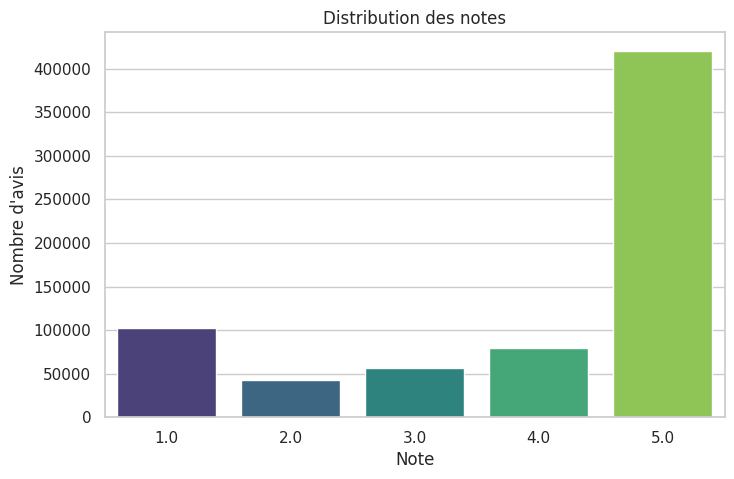

/tmp/ipykernel_4259/613970806.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='target_class', palette='Set2')


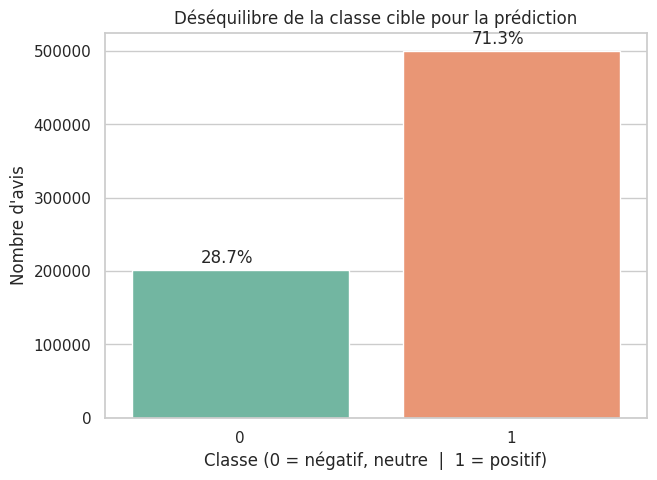

/tmp/ipykernel_4259/613970806.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='has_emoji', ax=axes[0], palette='Pastel1')
/tmp/ipykernel_4259/613970806.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Sans émoji', 'Avec émojis'])
/tmp/ipykernel_4259/613970806.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='has_caps', ax=axes[1], palette='Pastel2')
/tmp/ipykernel_4259/613970806.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Norm

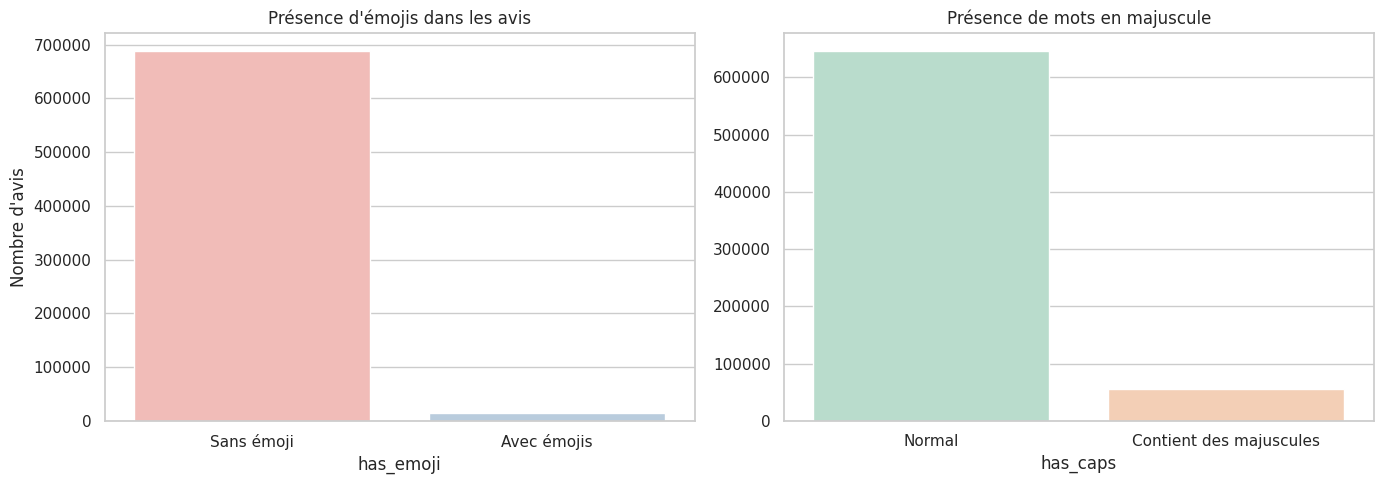

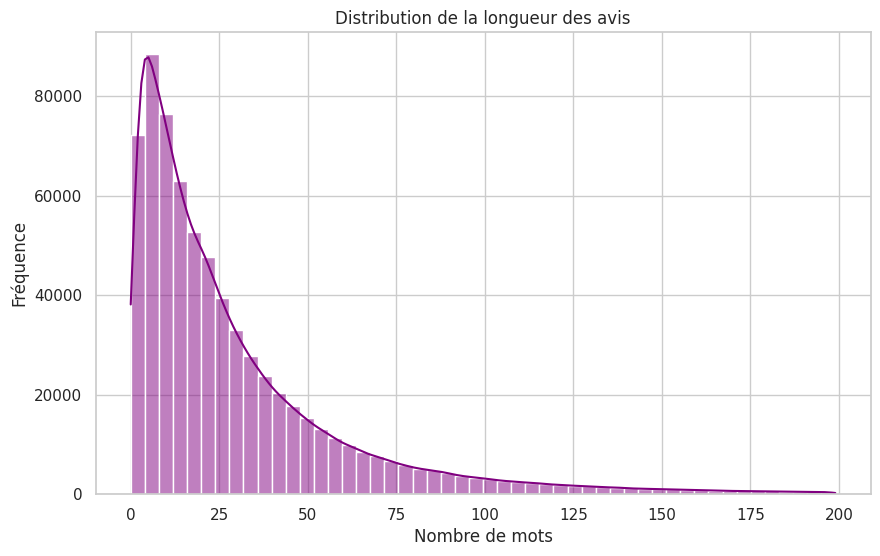


Aucune valeur manquante de type 'NaN' détectée à tracer.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import emoji
import re
from datasets import load_dataset

#Config style des graphes
sns.set_theme(style="whitegrid")

df = dataset['train'].to_pandas()

print("Génération des graphiques d'analyse...")

# Distribution de la variable cible
df['target_class'] = df['rating'].apply(lambda x: 1 if x >= 4 else 0)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='rating', palette='viridis')
plt.title('Distribution des notes')
plt.xlabel('Note')
plt.ylabel("Nombre d'avis")
plt.show()


#Désequilibre de la variable cible
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='target_class', palette='Set2')
plt.title('Déséquilibre de la classe cible pour la prédiction')
plt.xlabel('Classe (0 = négatif, neutre  |  1 = positif)')
plt.ylabel("Nombre d'avis")

# Ajout des pourcentages directement sur les barres du graphique
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height()
    ax.annotate(percentage, (x, y), textcoords="offset points", xytext=(0, 5), ha='center')

plt.show()


#Bruit : Emojis, texte en majusucle
df['text'] = df['text'].astype(str)
df['has_emoji'] = df['text'].apply(lambda x: emoji.emoji_count(x) > 0)
df['has_caps'] = df['text'].apply(lambda x: bool(re.search(r'\b[A-Z]{3,}\b', x)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# graphique 1 : emojis
sns.countplot(data=df, x='has_emoji', ax=axes[0], palette='Pastel1')
axes[0].set_title("Présence d'émojis dans les avis")
axes[0].set_xticklabels(['Sans émoji', 'Avec émojis'])
axes[0].set_ylabel("Nombre d'avis")

# graphique 2 : majuscules
sns.countplot(data=df, x='has_caps', ax=axes[1], palette='Pastel2')
axes[1].set_title("Présence de mots en majuscule")
axes[1].set_xticklabels(['Normal', 'Contient des majuscules'])
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


#Taille des textes
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 6))
# On limite l'affichage à 200 mots car quelques avis géants  écraseraient le graphique
sns.histplot(df[df['word_count'] < 200]['word_count'], bins=50, kde=True, color='purple')
plt.title("Distribution de la longueur des avis")
plt.xlabel("Nombre de mots")
plt.ylabel('Fréquence')
plt.show()

#Valeurs manquantes
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0] # Filtre pour ne garder que les colonnes à problèmes

if not missing_data.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=missing_data.index, y=missing_data.values, palette='Reds_r')
    plt.title('Nombre de valeurs manquantes par colonne')
    plt.xlabel('Colonnes avec valeurs manquantes')
    plt.ylabel('Nombre de données manquantes')
    plt.xticks(rotation=45)
    plt.show()
else:
    print("\nAucune valeur manquante de type 'NaN' détectée à tracer.")

### Partie 2 -  Text Processing and Transformation

1- Stemming + BOW


In [ ]:
from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer
from nltk.stem import PorterStemmer
import re

# Fonction pour combiner le titre et le texte en gérant les valeurs absentes (None)
def combine_text(example):
    title = str(example['title']) if example['title'] is not None else ""
    text = str(example['text']) if example['text'] is not None else ""
    return {'combined_text': title + " " + text}

# On applique cette fonction à tout le dataset (c'est très rapide avec Hugging Face)
dataset_prepared = dataset.map(combine_text)

# Extraction d'un ÉCHANTILLON pour l'entraînement
SAMPLE_SIZE = 701528
documents = dataset_prepared['train']['combined_text'][:SAMPLE_SIZE]

print(f"{len(documents)} documents extraits avec succès.")

# ---------------------------------------------------------
# 2. FONCTION D'ANALYSE (Stemming)
# ---------------------------------------------------------
stemmer = PorterStemmer()

def stem_tokenizer(text):
    # Extraction des mots (2 caractères ou plus)
    tokens = re.findall(r'(?u)\b\w\w+\b', text.lower())
    # Application du stemming sur chaque mot
    return [stemmer.stem(token) for token in tokens]

# ---------------------------------------------------------
# 3. VECTORISATION (Scikit-Learn)
# ---------------------------------------------------------
print("Vectorisation en cours (cela peut prendre un peu de temps)...")

# Configuration du CountVectorizer
vectorizer = CountVectorizer(
    tokenizer=stem_tokenizer,
    stop_words='english',
    lowercase=True,
    ngram_range=(1, 2),
    token_pattern=None,
    max_features=1500               # Pour le topic modeling, 1000 à 2000 features suffisent amplement
)

# Transformation des documents textuels en matrice mathématique
X_bow = vectorizer.fit_transform(documents)

# ---------------------------------------------------------
# 4. RÉSULTATS
# ---------------------------------------------------------
feature_names = vectorizer.get_feature_names_out()

print("\n--- Opération terminée ---")
print(f"Taille de la matrice Bag of Words : {X_bow.shape} (Documents x Mots-clés)")
print("\nAperçu du vocabulaire extrait (10 premiers termes) :")
print(feature_names[:10])

Map:   0%|          | 0/701528 [00:00<?, ? examples/s]

701528 documents extraits avec succès.
Vectorisation en cours (cela peut prendre un peu de temps)...


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'formerli', 'forti', 'ha', 'henc', 'hereaft', 'herebi', 'hi', 'howev', 'hundr', 'inde', 'latterli', 'mani', 'meanwhil', 'moreov', 'mostli', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'seriou', 'sever', 'sinc', 'sincer', 'sixti', 'someon', 'someth', 'sometim', 'somewher', 'themselv', 'thenc', 'thereaft', 'therebi', 'therefor', 'thi', 'thu', 'togeth', 'twelv', 'twenti', 'veri', 'wa', 'whatev', 'whenc', 'whenev', 'wherea', 'whereaft', 'wherebi', 'wherev', 'whi', 'yourselv'] not in stop_words.
  warnings


--- Opération terminée ---
Taille de la matrice Bag of Words : (701528, 1500) (Documents x Mots-clés)

Aperçu du vocabulaire extrait (10 premiers termes) :
['10' '100' '12' '14' '15' '16' '18' '20' '24' '30']


2- TF-IDF & Lemmatisation

In [ ]:
import spacy
import re
from bs4 import BeautifulSoup
from sklearn.feature_extraction.text import TfidfVectorizer

#1. Nettoyer le texte
def nettoyer_texte(text):
  if text is None:
    return ""
  text = BeautifulSoup(text, "html.parser").get_text()
  text = re.sub(r'[^\x00-\x7F]+', ' ', text)           # emojis/unicode
  text = re.sub(r'[^a-zA-Z\s]', ' ', text)             # chiffres/ponctuation
  text = re.sub(r'\s+', ' ', text).strip()              # espaces multiples
  return text.lower()

#2. Lemmatisation
nlp = spacy.load("en_core_web_sm")
def lemma_tokenizer(text):
  text = nettoyer_texte(text)
  doc = nlp(text)
  return [
      token.lemma_
      for token in doc
      if not token.is_stop # le token n'est pas un stopword
      and not token.is_punct # retire la ponctuation
      and len(token.lemma_) > 2 # retire les mots courts
  ]

#3. TF_IDF:
tfidf_vectorizer = TfidfVectorizer(
    tokenizer = lemma_tokenizer,
    lowercase = True,
    ngram_range = (1,2),
    max_features = 1500
)

X_tfidf_lemma = tfidf_vectorizer.fit_transform(documents)
print(f"Matrice TF-IDF + Lemmatisation : {X_tfidf_lemma.shape}")




/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


KeyboardInterrupt: 

### 3 - LSTM / GLOVE

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from datasets import load_dataset

# ---------------------------------------------------------
# 1. PRÉPARATION DES DONNÉES
# ---------------------------------------------------------
print("1. Préparation du dataset...")

#
# dataset = load_dataset('json', data_files='/content/drive/MyDrive/data/All_Beauty.jsonl')

def prepare_features(example):
    """
    Combine le titre et le texte, et crée un label binaire à partir du rating.
    """
    # Gestion des valeurs manquantes (None)
    title = str(example['title']) if example['title'] is not None else ""
    text = str(example['text']) if example['text'] is not None else ""

    # 1 pour avis positif (rating >= 4), 0 pour avis négatif/neutre (< 4)
    rating = example['rating'] if example['rating'] is not None else 3.0
    label = 1 if rating >= 4 else 0

    return {
        'combined_text': title + " " + text,
        'label': label
    }

# Application de la fonction sur le dataset
dataset_prepared = dataset.map(prepare_features)

# EXTRACTION D'UN ÉCHANTILLON
# Le dataset complet (701 528 lignes) est trop gros pour la RAM d'un Colab standard sans générateurs.
# On prend les 50 000 premiers avis pour tester.
SAMPLE_SIZE = 50000
texts = dataset_prepared['train']['combined_text'][:SAMPLE_SIZE]
labels = np.array(dataset_prepared['train']['label'][:SAMPLE_SIZE])

print(f"{len(texts)} documents extraits pour l'entraînement.")

# ---------------------------------------------------------
# 2. TOKENISATION SÉQUENTIELLE ET PADDING
# ---------------------------------------------------------
print("2. Tokenisation des séquences...")

VOCAB_SIZE = 10000      # On garde les 10 000 mots les plus fréquents
MAX_SEQ_LENGTH = 100    # On limite les phrases à 100 mots (tronquées si plus long)
EMBEDDING_DIM = 100     # Dimension des vecteurs GloVe (assurez-vous d'avoir le fichier 100d)

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

# Conversion des textes en suites d'entiers
sequences = tokenizer.texts_to_sequences(texts)

# Padding : harmonisation de la taille de toutes les séquences
X_data = pad_sequences(sequences, maxlen=MAX_SEQ_LENGTH, padding='post', truncating='post')

print(f"Format de la matrice d'entrée : {X_data.shape}")

# ---------------------------------------------------------
# 3. CHARGEMENT DE GLOVE
# ---------------------------------------------------------
print("3. Chargement des embeddings GloVe...")
embeddings_index = {}

# Renseignez le bon chemin vers votre fichier GloVe téléchargé
GLOVE_PATH = '/content/drive/MyDrive/data/glove.6B.100d.txt'

try:
    with open(GLOVE_PATH, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    print(f"{len(embeddings_index)} vecteurs GloVe chargés en mémoire.")
except FileNotFoundError:
    print("ERREUR: Fichier GloVe introuvable ! Vérifiez le chemin d'accès.")

# Création de la matrice de poids pour NOTRE vocabulaire
word_index = tokenizer.word_index
num_words = min(VOCAB_SIZE, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, EMBEDDING_DIM))

for word, i in word_index.items():
    if i >= VOCAB_SIZE:
        continue # On ignore les mots en dehors du top VOCAB_SIZE
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # Les mots non trouvés dans GloVe seront à 0 (padding ou mots rares)
        embedding_matrix[i] = embedding_vector

# ---------------------------------------------------------
# 4. CONSTRUCTION ET ENTRAÎNEMENT DU MODÈLE LSTM
# ---------------------------------------------------------
print("4. Construction du modèle LSTM...")

model = Sequential([
    # Couche d'embedding initialisée avec GloVe
    Embedding(
        input_dim=num_words,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_SEQ_LENGTH,
        trainable=False # Crucial : On ne modifie pas les poids de GloVe pendant l'entraînement !
    ),

    # Couche LSTM
    LSTM(128, return_sequences=False),

    # Dropout pour limiter le surapprentissage (overfitting)
    Dropout(0.5),

    # Couche de sortie pour la classification binaire (Positif vs Négatif)
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

print("\n5. Démarrage de l'entraînement...")
# Validation split de 0.2 signifie qu'il garde 20% des 50 000 exemples pour tester la précision en direct
history = model.fit(X_data, labels, epochs=5, batch_size=64, validation_split=0.2, verbose=1)

1. Préparation du dataset...


Map:   0%|          | 0/701528 [00:00<?, ? examples/s]

KeyboardInterrupt: 

In [ ]:
import numpy as np
import re
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# ---------------------------------------------------------
# 1. PRÉPARATION DES DONNÉES (Adapté à votre Dataset)
# ---------------------------------------------------------
print("1. Préparation du dataset...")

# dataset = load_dataset('json', data_files='/content/drive/MyDrive/data/All_Beauty.jsonl')

def prepare_features(example):
    title = str(example['title']) if example['title'] is not None else ""
    text = str(example['text']) if example['text'] is not None else ""
    # Label binaire : 1 pour avis positif (rating >= 4), 0 pour négatif/neutre (< 4)
    rating = example['rating'] if example['rating'] is not None else 3.0
    return {
        'combined_text': title + " " + text,
        'label': 1 if rating >= 4 else 0
    }

dataset_prepared = dataset.map(prepare_features)

# On extrait un échantillon pour l'entraînement (par exemple 20 000 avis)
SAMPLE_SIZE = 20000
documents = dataset_prepared['train']['combined_text'][:SAMPLE_SIZE]
labels = dataset_prepared['train']['label'][:SAMPLE_SIZE]

# ---------------------------------------------------------
# 2. CHARGEMENT DU DICTIONNAIRE GLOVE
# ---------------------------------------------------------
print("2. Chargement du modèle GloVe en mémoire...")

GLOVE_PATH = 'glove.6B.100d.txt' # Assurez-vous d'avoir ce fichier
glove_dict = {}
EMBEDDING_DIM = 100

try:
    with open(GLOVE_PATH, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            glove_dict[word] = vector
    print(f"{len(glove_dict)} mots chargés depuis GloVe.")
except FileNotFoundError:
    print("ERREUR: Fichier GloVe introuvable.")

# ---------------------------------------------------------
# 3. CRÉATION DES VECTEURS DE DOCUMENTS (Moyenne des mots)
# ---------------------------------------------------------
print("3. Transformation des textes en vecteurs GloVe moyens...")

def document_to_glove_vector(text, model_dict, dim):
    """
    Extrait les mots du texte, récupère leur vecteur GloVe, et calcule la moyenne.
    """
    # Tokenisation très simple (mots en minuscules)
    words = re.findall(r'(?u)\b\w\w+\b', text.lower())

    # On récupère les vecteurs des mots qui existent dans GloVe
    word_vectors = [model_dict[word] for word in words if word in model_dict]

    # Si aucun mot n'est trouvé dans GloVe, on retourne un vecteur de zéros
    if len(word_vectors) == 0:
        return np.zeros(dim)

    # On calcule la moyenne de la liste des vecteurs sur l'axe 0
    return np.mean(word_vectors, axis=0)

# On applique la fonction à tout notre corpus
X_glove = np.array([document_to_glove_vector(doc, glove_dict, EMBEDDING_DIM) for doc in documents])
y = np.array(labels)

print(f"Format de la matrice de données : {X_glove.shape} (Documents x Dimensions GloVe)")

# ---------------------------------------------------------
# 4. ENTRAÎNEMENT AVEC SCIKIT-LEARN (Partie 4 du projet)
# ---------------------------------------------------------
print("4. Entraînement du modèle Scikit-Learn...")

# Séparation des données en Train (80%) et Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X_glove, y, test_size=0.2, random_state=42)

# On utilise une Régression Logistique (rapide et efficace sur des embeddings denses)
# Vous pouvez aussi tester SVM (SVC) ou Random Forest
classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train, y_train)

# ---------------------------------------------------------
# 5. RÉSULTATS ET VALIDATION (Partie 5 du projet)
# ---------------------------------------------------------
print("\n--- ÉVALUATION DU MODÈLE ---")
y_pred = classifier.predict(X_test)

print(f"Accuracy Globale : {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Rapport de classification détaillé :")
print(classification_report(y_test, y_pred, target_names=["Négatif/Neutre (0)", "Positif (1)"]))

1. Préparation du dataset...


Map:   0%|          | 0/701528 [00:00<?, ? examples/s]

2. Chargement du modèle GloVe en mémoire...
ERREUR: Fichier GloVe introuvable.
3. Transformation des textes en vecteurs GloVe moyens...
Format de la matrice de données : (20000, 100) (Documents x Dimensions GloVe)
4. Entraînement du modèle Scikit-Learn...

--- ÉVALUATION DU MODÈLE ---
Accuracy Globale : 73.78%

Rapport de classification détaillé :
                    precision    recall  f1-score   support

Négatif/Neutre (0)       0.00      0.00      0.00      1049
       Positif (1)       0.74      1.00      0.85      2951

          accuracy                           0.74      4000
         macro avg       0.37      0.50      0.42      4000
      weighted avg       0.54      0.74      0.63      4000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


###3-Word2Vec

In [ ]:
import re
import numpy as np
from gensim.models import Word2Vec

#1.Tokenization simple
def simple_tokenizer(text):
  if text is None:
    return []
  text = text.lower()
  tokens = re.findall(r'(?u)\b\w\w+\b', text)
  return tokens

tokenized_docs = []
for doc in documents:
  tokenized_docs.append(simple_tokenizer(doc))
#documents[0] = "Such a lovely scent! This spray is really nice."
                        #↓ simple_tokenize
#tokenized_docs[0] = ["such", "lovely", "scent", "this", "spray",
#"is", "really", "nice"]

#2. Word2Vec (vectoriser chaque token de tokenized_docs)
print("Entrainement de Word2Vec...")

Word2Vec_Model = Word2Vec(
    sentences=tokenized_docs,  # liste de listes de tokens
    vector_size=100,            # dimension des vecteurs
    window=5,                   # contexte ±5 mots
    min_count=2,                # ignore les mots qui apparaissent < 2 fois
    workers=4,                  # parallélisation CPU
    epochs=5,                   # nombre de passes sur le corpus
    sg=1                        # 1 = Skip-gram, 0 = CBOW
)
print(f"Vocabulaire appris : {len(Word2Vec_Model.wv)} mots")

# Vérification — mots similaires à "good"
print("Mots proches de 'good' :")
print(Word2Vec_Model.wv.most_similar("good", topn=5)) #Similarité cosinus





Entrainement de Word2Vec...
Vocabulaire appris : 51167 mots
Mots proches de 'good' :
[('great', 0.8326209783554077), ('nice', 0.7835121154785156), ('decent', 0.7784610390663147), ('gret', 0.7668499946594238), ('grat', 0.7559115290641785)]


In [ ]:
#3.Création des vecteurs de documents
def doc_vector_w2v(tokens, model):
    vecs = [model.wv[w] for w in tokens if w in model.wv]

    # Si aucun mot trouvé → vecteur de zéros
    if len(vecs) == 0:
        return np.zeros(model.vector_size)

    # Moyenne de tous les vecteurs de mots
    return np.mean(vecs, axis=0)

X_w2v = np.array([doc_vector_w2v(tokens, Word2Vec_Model)
                  for tokens in tokenized_docs])

print(f"Matrice Word2Vec : {X_w2v.shape}")
# → (50000, 100)

Matrice Word2Vec : (701528, 100)


###3.BERT

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

#1. On charge le module
print("Chargement du modèle Sentence Bert")
model_sbert = SentenceTransformer('all-MiniLM-L6-v2')

#2.On fait un échantillonage
Sample_size = 10000
documents_sample_bert = dataset_prepared['train']['combined_text'][:Sample_size]

#3.Le modèle
X_sbert = model_sbert.encode(
    documents_sample_bert,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"Matrice Sentence-BERT : {X_sbert.shape}")
# → (10000, 384)



Chargement du modèle Sentence Bert


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Matrice Sentence-BERT : (10000, 384)


In [ ]:
# 1 si rating >= 4 (positif), 0 sinon (négatif/neutre)
labels_tfidf = np.array([
    1 if r >= 4 else 0
    for r in dataset_prepared['train']['rating'][:50000]
])

labels_w2v = np.array([
    1 if r >= 4 else 0
    for r in dataset_prepared['train']['rating'][:701528]
])

labels_sbert = np.array([
    1 if r >= 4 else 0
    for r in dataset_prepared['train']['rating'][:10000]
])

# Vérifie la distribution
from collections import Counter
print("TF-IDF labels :", Counter(labels_tfidf))
print("W2V labels    :", Counter(labels_w2v))
print("SBERT labels  :", Counter(labels_sbert))

TF-IDF labels : Counter({np.int64(1): 37034, np.int64(0): 12966})
W2V labels    : Counter({np.int64(1): 500107, np.int64(0): 201421})
SBERT labels  : Counter({np.int64(1): 7584, np.int64(0): 2416})


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

def evaluate_lr(X, y, name):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    clf = LogisticRegression(
        max_iter=1000,
        class_weight='balanced',  # corrige déséquilibre
        n_jobs=-1
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy : {acc*100:.2f}%")
    print(classification_report(
        y_test, y_pred,
        target_names=['Négatif/Neutre (0)', 'Positif (1)']
    ))
    return acc

# Évaluation
acc_w2v   = evaluate_lr(X_w2v,         labels_w2v,   "Word2Vec")
acc_sbert = evaluate_lr(X_sbert,       labels_sbert, "Sentence-BERT")

# Comparaison finale
print("\n========= COMPARAISON FINALE =========")
print(f"Word2Vec               : {acc_w2v*100:.2f}%")
print(f"Sentence-BERT          : {acc_sbert*100:.2f}%")

Accuracy : 89.13%
                    precision    recall  f1-score   support

Négatif/Neutre (0)       0.76      0.90      0.83     40284
       Positif (1)       0.96      0.89      0.92    100022

          accuracy                           0.89    140306
         macro avg       0.86      0.90      0.87    140306
      weighted avg       0.90      0.89      0.89    140306

Accuracy : 84.75%
                    precision    recall  f1-score   support

Négatif/Neutre (0)       0.64      0.84      0.73       483
       Positif (1)       0.94      0.85      0.89      1517

          accuracy                           0.85      2000
         macro avg       0.79      0.85      0.81      2000
      weighted avg       0.87      0.85      0.85      2000


========= COMPARAISON FINALE =========
Word2Vec               : 89.13%
Sentence-BERT          : 84.75%


In [ ]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
import numpy as np

# ---------------------------------------------------------
# 1. PRÉPARATION ET ENTRAÎNEMENT DE DOC2VEC
# ---------------------------------------------------------
print("1. Préparation des données pour Doc2Vec...")

# Doc2Vec nécessite un format spécifique : TaggedDocument
# Il associe une liste de tokens à un identifiant unique (tag)
# On utilise la liste 'tokenized_docs' que tu avais créée pour Word2Vec
tagged_data = [TaggedDocument(words=doc, tags=[str(i)]) for i, doc in enumerate(tokenized_docs)]

print("2. Entraînement du modèle Doc2Vec (cela peut prendre quelques minutes)...")
model_d2v = Doc2Vec(
    vector_size=100,  # Dimension du vecteur (identique à Word2Vec pour comparer)
    window=5,         # Fenêtre de contexte
    min_count=2,      # Ignore les mots apparaissant moins de 2 fois
    workers=4,        # Utilisation de tous les cœurs du CPU
    epochs=10         # 10 passes sur le dataset pour bien apprendre le contexte global
)

# Construction du vocabulaire et entraînement
model_d2v.build_vocab(tagged_data)
model_d2v.train(tagged_data, total_examples=model_d2v.corpus_count, epochs=model_d2v.epochs)

print("3. Extraction des vecteurs...")
# On extrait le vecteur final pour chaque document grâce à son tag (l'index 'i')
X_d2v = np.array([model_d2v.dv[str(i)] for i in range(len(tagged_data))])
print(f"Matrice Doc2Vec : {X_d2v.shape} (Documents x Dimensions)")


# ---------------------------------------------------------
# 2. ÉVALUATION MACHINE LEARNING (Comparaison Globale)
# ---------------------------------------------------------
print("\n========= ÉVALUATION MACHINE LEARNING =========")

# On recrée les labels pour s'assurer qu'ils ont exactement la même taille que 'documents'
# (Utile si tu as réduit le SAMPLE_SIZE pour des raisons de RAM)
labels_ml = np.array([1 if r >= 4 else 0 for r in dataset_prepared['train']['rating'][:len(documents)]])

# 1. Évaluation de Doc2Vec
acc_d2v = evaluate_lr(X_d2v, labels_ml, "Document2Vec")

# 2. Évaluation de TF-IDF
# La matrice X_tfidf_lemma est "creuse" (Sparse Matrix), mais Scikit-Learn (LogisticRegression)
# est extrêmement bien optimisé pour la traiter très rapidement.
if 'X_tfidf_lemma' in locals():
    acc_tfidf = evaluate_lr(X_tfidf_lemma, labels_ml, "TF-IDF + Lemmatisation")
else:
    print("La matrice X_tfidf_lemma n'est pas définie dans la mémoire actuelle.")

# 3. Évaluation du Bag of Words (BoW)
if 'X_bow' in locals():
    acc_bow = evaluate_lr(X_bow, labels_ml, "Bag of Words (BoW) + Stemming")
else:
    print("La matrice X_bow n'est pas définie dans la mémoire actuelle.")


# ---------------------------------------------------------
# 3. RÉCAPITULATIF (Pour tes slides)
# ---------------------------------------------------------
print("\n========= CLASSEMENT FINAL DES PERFORMANCES =========")
if 'acc_bow' in locals(): print(f"1. Bag of Words      : {acc_bow*100:.2f}%")
if 'acc_tfidf' in locals(): print(f"2. TF-IDF            : {acc_tfidf*100:.2f}%")
print(f"3. Document2Vec      : {acc_d2v*100:.2f}%")
# Si acc_sbert et acc_w2v sont encore en mémoire, tu peux les rajouter ici !

1. Préparation des données pour Doc2Vec...
2. Entraînement du modèle Doc2Vec (cela peut prendre quelques minutes)...
3. Extraction des vecteurs...
Matrice Doc2Vec : (701528, 100) (Documents x Dimensions)

========= ÉVALUATION MACHINE LEARNING =========
Accuracy : 79.86%
                    precision    recall  f1-score   support

Négatif/Neutre (0)       0.62      0.75      0.68     40284
       Positif (1)       0.89      0.82      0.85    100022

          accuracy                           0.80    140306
         macro avg       0.76      0.78      0.77    140306
      weighted avg       0.81      0.80      0.80    140306

La matrice X_tfidf_lemma n'est pas définie dans la mémoire actuelle.
Accuracy : 87.05%
                    precision    recall  f1-score   support

Négatif/Neutre (0)       0.73      0.88      0.80     40284
       Positif (1)       0.95      0.87      0.91    100022

          accuracy                           0.87    140306
         macro avg       0.84      0.

###4. Traitement d'images + jointure

In [ ]:
print("Colonnes produits...")
print(df.columns.to_list())

Colonnes produits...
['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']


In [ ]:
#Exemple d'image:
print("Exemple d'image:")
print(df["images"].iloc[0])

Exemple d'image:
{'hi_res': array([None,
       'https://m.media-amazon.com/images/I/71i77AuI9xL._SL1500_.jpg'],
      dtype=object), 'large': array(['https://m.media-amazon.com/images/I/41qfjSfqNyL.jpg',
       'https://m.media-amazon.com/images/I/41w2yznfuZL.jpg'],
      dtype=object), 'thumb': array(['https://m.media-amazon.com/images/I/41qfjSfqNyL._SS40_.jpg',
       'https://m.media-amazon.com/images/I/41w2yznfuZL._SS40_.jpg'],
      dtype=object), 'variant': array(['MAIN', 'PT01'], dtype=object)}


In [ ]:
# Fonction pour combiner le titre et le texte en gérant les valeurs absentes (None)
def combine_text(example):
    title = str(example['title']) if example['title'] is not None else ""
    text = str(example['text']) if example['text'] is not None else ""
    return {'combined_text': title + " " + text}

# On applique cette fonction à tout le dataset
dataset_prepared = dataset.map(combine_text)
print("Colonnes d'avis...")
print(dataset_prepared['train'].column_names)


Map:   0%|          | 0/701528 [00:00<?, ? examples/s]

Colonnes d'avis...
['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'combined_text']


In [ ]:
#Extraire les images des dictionnaires d'url qu'on a
def get_image(images_dict):
  try:
    # Prend la première URL 'large' disponible
    for url in images_dict['large']:
      if url is not None:
        return url
    return None
  except:
    return None

# Recharge le parquet original
df = pd.read_parquet('/content/drive/MyDrive/data/full-00000-of-00001.parquet')

# Stocke dans une nouvelle colonne image_url
df['image_url'] = df['images'].apply(get_image)

print(f"Produits avec image : {df['image_url'].notna().sum()}")
print()
print("Exemple URL :")
print(df['image_url'].dropna().iloc[0])


Produits avec image : 112590

Exemple URL :
https://m.media-amazon.com/images/I/41qfjSfqNyL.jpg


In [ ]:
import pandas as pd

SAMPLE = 5000

df_reviews = pd.DataFrame({
    'combined_text' : dataset_prepared['train']['combined_text'][:SAMPLE],
    'rating'        : dataset_prepared['train']['rating'][:SAMPLE],
    'parent_asin'   : dataset_prepared['train']['parent_asin'][:SAMPLE],
    'label'         : [1 if r >= 4 else 0
                       for r in dataset_prepared['train']['rating'][:SAMPLE]]
})

print(f"Avis extraits : {len(df_reviews)}")


# => JOINTURE via parent_asin
df_merged = df_reviews.merge(
    df[['parent_asin', 'image_url']],  # ← df = ton parquet
    on='parent_asin',
    how='inner'
)

print(f"Après jointure : {len(df_merged)} avis avec image")
print()
print(df_merged[['combined_text', 'rating', 'image_url']].head(3))

Avis extraits : 5000
Après jointure : 5000 avis avec image

                                                                                                                                                                                                                                                                                                                                            combined_text  \
0  Such a lovely scent but not overpowering. This spray is really nice. It smells really good, goes on really fine, and does the trick. I will say it feels like you need a lot of it though to get the texture I want. I have a lot of hair, medium thickness. I am comparing to other brands with yucky chemicals so I'm gonna stick with this. Try it!   
1                                                                      Works great but smells a little weird. This product does what I need it to do, I just wish it was odorless or had a soft coconut smell. Having my head smell like an orange

###5. Concaténation des vecteurs images + textes

In [ ]:
import requests
import numpy as np
from PIL import Image
from io import BytesIO
import torch
import torchvision.models as models
import torchvision.transforms as transforms

# 1. Charger resnet 50 SANS LA DERNIÈRE COUCHE
print("Chargement ResNet50...")

resnet = models.resnet50(pretrained=True)
resnet = torch.nn.Sequential(*list(resnet.children())[:-1])
resnet.eval()

print("ResNet50 chargé ")

# 2. Preprocessing Image
transform = transforms.Compose([
    transforms.Resize((224, 224)),        # resize
    transforms.ToTensor(),                # → tensor
    transforms.Normalize(                 # normalize ImageNet
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 3. Fonction Encoder une image
def encode_image(url):
    try:
        #Télécharge l'image
        response = requests.get(url, timeout=5)
        img = Image.open(BytesIO(response.content)).convert('RGB')

        #Preprocessing
        tensor = transform(img).unsqueeze(0)

        #ResNet50
        with torch.no_grad():
            features = resnet(tensor)

        #Reshape → vecteur 1D de 2048 dims
        return features.squeeze().numpy()

    except:
        #Si erreur → vecteur de zéros
        return np.zeros(2048)

print("Encoding des images...")

image_embeddings = []
for i, url in enumerate(df_merged['image_url']):
    vec = encode_image(url)
    image_embeddings.append(vec)
    if i % 500 == 0:
        print(f"{i}/{len(df_merged)} images encodées...")

X_images = np.array(image_embeddings)
print(f"\nMatrice images : {X_images.shape}")
# → (5000, 2048)

Chargement ResNet50...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 70.3MB/s]


ResNet50 chargé ✅
Encoding des images...
0/5000 images encodées...
500/5000 images encodées...
1000/5000 images encodées...
1500/5000 images encodées...
2000/5000 images encodées...
2500/5000 images encodées...
3000/5000 images encodées...
3500/5000 images encodées...
4000/5000 images encodées...
4500/5000 images encodées...

Matrice images : (5000, 2048)


In [ ]:
#Encoder le texte des mêmes 5000 docs en utilisant SBert
from sentence_transformers import SentenceTransformer
import numpy as np

model_sbert = SentenceTransformer('all-MiniLM-L6-v2')

print("Encoding texte...")
X_text = model_sbert.encode(
    df_merged['combined_text'].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"Texte  : {X_text.shape}")   # (5000, 384)
print(f"Images : {X_images.shape}") # (5000, 2048)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding texte...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Texte  : (5000, 384)
Images : (5000, 2048)


In [ ]:
import numpy as np
from sklearn.preprocessing import normalize
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

#1. Normalisation des deux vecteurs(L2)
X_text_norm = normalize(X_text)
X_images_norm = normalize(X_images)

#2. Concaténation des deux vecteurs
X_multimodal = np.concatenate((X_text_norm, X_images_norm), axis = 1)
print(f"Multimodal       : {X_multimodal.shape}")
# → (5000, 2432)

#3.Label
y = np.array(df_merged['label'])

#4.Classification texte seul + multimodal
def evaluate_lr(X,y,name):
  print(f"\n----{name}-------")

  X_train, X_test, y_train, y_test = train_test_split(
      X,y,
      test_size =0.2,
      random_state =42,
      stratify = y
  )

  clf = LogisticRegression(
      max_iter =1000,
      class_weight = 'balanced',
      n_jobs = -1
  )

  clf.fit(X_train,y_train)
  y_pred = clf.predict(X_test)

  acc = accuracy_score(y_test, y_pred)
  print(f"Accuracy : {acc*100:.2f}%")
  print(classification_report(
        y_test, y_pred,
        target_names=['Négatif (0)', 'Positif (1)']
    ))
  return acc


# 5. COMPARAISON
acc_text  = evaluate_lr(X_text_norm,  y, "Texte seul (SBERT)")
acc_multi = evaluate_lr(X_multimodal, y, "Texte + Image (Multimodal)")

print("\n========= COMPARAISON FINALE =========")
print(f"Texte seul  : {acc_text*100:.2f}%")
print(f"Multimodal  : {acc_multi*100:.2f}%")
print(f"Gain        : +{(acc_multi - acc_text)*100:.2f}%")



Multimodal       : (5000, 2432)

----Texte seul (SBERT)-------
Accuracy : 82.20%
              precision    recall  f1-score   support

 Négatif (0)       0.58      0.77      0.66       227
 Positif (1)       0.93      0.84      0.88       773

    accuracy                           0.82      1000
   macro avg       0.75      0.80      0.77      1000
weighted avg       0.85      0.82      0.83      1000


----Texte + Image (Multimodal)-------
Accuracy : 82.10%
              precision    recall  f1-score   support

 Négatif (0)       0.58      0.75      0.66       227
 Positif (1)       0.92      0.84      0.88       773

    accuracy                           0.82      1000
   macro avg       0.75      0.80      0.77      1000
weighted avg       0.84      0.82      0.83      1000


========= COMPARAISON FINALE =========
Texte seul  : 82.20%
Multimodal  : 82.10%
Gain        : +-0.10%


L'image dans notre cas n'aide pas du tout concernant l'avis parce que c'est l'image du produit logiquemment elle rapporte aucune information sur l'avis d'une client